In [1]:
import polars as pl

In [2]:
ds = pl.scan_parquet("/zata/zippy/kresgeb/nmf_stuff/dlPFC/data/batched_nmf/all_patterns_partitioned")

In [3]:
non_zero = ds.filter(pl.col("loading") > 0)

In [4]:
test_k = 80
test_tol = 1e-6
test_L1 = 0.1

test_set = (
    non_zero.with_columns(pl.col("loading").cast(pl.Float32))
    .filter(
        (pl.col("k") == test_k)
        & (pl.col("tol") == test_tol)
        & (pl.col("L1") == test_L1)
    )
    .with_columns([pl.struct(["run_id", "pattern"]).hash().alias("pattern_uid")])
)

In [5]:
print(test_set)

naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

 WITH_COLUMNS:
 [col("run_id").as_struct([col("pattern")]).hash().alias("pattern_uid")] 
  FILTER [(col("L1")) == (0.1)]
  FROM
    FILTER [(col("tol")) == (0.000001)]
    FROM
      FILTER [(col("k")) == (80)]
      FROM
         WITH_COLUMNS:
         [col("loading").cast(Float32)] 
          FILTER [(col("loading")) > (0.0)]
          FROM
            Parquet SCAN [/zata/zippy/kresgeb/nmf_stuff/dlPFC/data/batched_nmf/all_patterns_partitioned/k=10/part-0.parquet, ... 9 other sources]
            PROJECT */8 COLUMNS
            ESTIMATED ROWS: 274507500


In [6]:
df = test_set.collect()
print(df)

shape: (1_880_948, 9)
┌────────┬─────────┬───────────┬──────────┬───┬──────────┬─────┬─────┬──────────────────────┐
│ run_id ┆ pattern ┆ gene      ┆ loading  ┆ … ┆ tol      ┆ L1  ┆ k   ┆ pattern_uid          │
│ ---    ┆ ---     ┆ ---       ┆ ---      ┆   ┆ ---      ┆ --- ┆ --- ┆ ---                  │
│ i32    ┆ i32     ┆ str       ┆ f32      ┆   ┆ f64      ┆ f64 ┆ i64 ┆ u64                  │
╞════════╪═════════╪═══════════╪══════════╪═══╪══════════╪═════╪═════╪══════════════════════╡
│ 58     ┆ 1       ┆ LINC01409 ┆ 0.000069 ┆ … ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 4315335196037242044  │
│ 58     ┆ 2       ┆ LINC01409 ┆ 0.000055 ┆ … ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 18166103677675900244 │
│ 58     ┆ 3       ┆ LINC01409 ┆ 0.00005  ┆ … ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 1597032879543952224  │
│ 58     ┆ 5       ┆ LINC01409 ┆ 0.000024 ┆ … ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 15433820534915496637 │
│ 58     ┆ 8       ┆ LINC01409 ┆ 0.000046 ┆ … ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 16286261502328847262 │
│ …      ┆ …       ┆ …         ┆ …    

In [7]:
df = df.with_columns(
    [
        pl.col("pattern_uid").rank(method="dense").cast(pl.UInt32).alias("row_idx")
        - 1,  # needed to be 0-indexed
        
        pl.col("gene")
        .cast(pl.Categorical)  # convert to categorical
        .cast(pl.UInt32)  # convert category codes → integer indices
        .alias("col_idx"),
    ]
)

print(df)

shape: (1_880_948, 11)
┌────────┬─────────┬───────────┬──────────┬───┬─────┬──────────────────────┬─────────┬─────────┐
│ run_id ┆ pattern ┆ gene      ┆ loading  ┆ … ┆ k   ┆ pattern_uid          ┆ row_idx ┆ col_idx │
│ ---    ┆ ---     ┆ ---       ┆ ---      ┆   ┆ --- ┆ ---                  ┆ ---     ┆ ---     │
│ i32    ┆ i32     ┆ str       ┆ f32      ┆   ┆ i64 ┆ u64                  ┆ u32     ┆ u32     │
╞════════╪═════════╪═══════════╪══════════╪═══╪═════╪══════════════════════╪═════════╪═════════╡
│ 58     ┆ 1       ┆ LINC01409 ┆ 0.000069 ┆ … ┆ 80  ┆ 4315335196037242044  ┆ 82      ┆ 0       │
│ 58     ┆ 2       ┆ LINC01409 ┆ 0.000055 ┆ … ┆ 80  ┆ 18166103677675900244 ┆ 389     ┆ 0       │
│ 58     ┆ 3       ┆ LINC01409 ┆ 0.00005  ┆ … ┆ 80  ┆ 1597032879543952224  ┆ 24      ┆ 0       │
│ 58     ┆ 5       ┆ LINC01409 ┆ 0.000024 ┆ … ┆ 80  ┆ 15433820534915496637 ┆ 328     ┆ 0       │
│ 58     ┆ 8       ┆ LINC01409 ┆ 0.000046 ┆ … ┆ 80  ┆ 16286261502328847262 ┆ 353     ┆ 0       │
│ …    

In [8]:
pattern_meta = df.select(pl.exclude("gene", "loading", "col_idx")).unique().sort("row_idx")

gene_meta = df.select("gene", "col_idx").unique().sort("col_idx")
print(pattern_meta)
print(gene_meta)

shape: (400, 8)
┌────────┬─────────┬────────┬──────────┬─────┬─────┬──────────────────────┬─────────┐
│ run_id ┆ pattern ┆ seed   ┆ tol      ┆ L1  ┆ k   ┆ pattern_uid          ┆ row_idx │
│ ---    ┆ ---     ┆ ---    ┆ ---      ┆ --- ┆ --- ┆ ---                  ┆ ---     │
│ i32    ┆ i32     ┆ i32    ┆ f64      ┆ f64 ┆ i64 ┆ u64                  ┆ u32     │
╞════════╪═════════╪════════╪══════════╪═════╪═════╪══════════════════════╪═════════╡
│ 68     ┆ 55      ┆ 1029   ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 134097434944810464   ┆ 0       │
│ 68     ┆ 19      ┆ 1029   ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 157783944762124317   ┆ 1       │
│ 98     ┆ 44      ┆ 2025   ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 196526819493413471   ┆ 2       │
│ 78     ┆ 77      ┆ 31415  ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 264039986569404696   ┆ 3       │
│ 88     ┆ 11      ┆ 120301 ┆ 0.000001 ┆ 0.1 ┆ 80  ┆ 271565227610112951   ┆ 4       │
│ …      ┆ …       ┆ …      ┆ …        ┆ …   ┆ …   ┆ …                    ┆ …       │
│ 68     ┆ 36      ┆ 1029   ┆ 0.000001

In [9]:
import numpy as np
from scipy.sparse import coo_matrix

rows = df["row_idx"].to_numpy()
cols = df["col_idx"].to_numpy()
vals = df["loading"].to_numpy()

n_rows = int(rows.max()) + 1
n_cols = int(cols.max()) + 1

mat = coo_matrix((vals, (rows, cols)), shape=(n_rows, n_cols)).tocsr()
print(mat)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1880932 stored elements and shape (400, 16476)>
  Coords	Values
  (0, 14)	1.1581165381358005e-05
  (0, 27)	0.00026419246569275856
  (0, 38)	4.723345773527399e-05
  (0, 63)	0.00031004220363684
  (0, 80)	6.070250674383715e-05
  (0, 83)	0.000641148944851011
  (0, 84)	0.0007681080023758113
  (0, 93)	0.0004451663407962769
  (0, 99)	0.00338859879411757
  (0, 115)	5.363487434806302e-05
  (0, 126)	0.00029080844251438975
  (0, 156)	0.00016076477186288685
  (0, 170)	0.0004277061379980296
  (0, 177)	0.004405562300235033
  (0, 181)	0.0002008741139434278
  (0, 185)	0.00014229513180907816
  (0, 186)	0.0014251898974180222
  (0, 190)	0.00041496200719848275
  (0, 193)	3.0361250537680462e-05
  (0, 214)	0.00017511614714749157
  (0, 230)	0.0006239002104848623
  (0, 240)	0.007197276223450899
  (0, 274)	0.0004749059153255075
  (0, 332)	0.00027706543914973736
  (0, 371)	8.123554289340973e-05
  :	:
  (399, 16284)	0.00013783031317871064
  (399, 1628

In [10]:
import umap
import numpy as np

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",  # IMPORTANT for NMF patterns
    # n_jobs=64,# for parallel (incompatible with random_state)
    random_state=42,  # for reproducibility (incompatible with n_jobs)
    verbose=True,
)

mapper = reducer.fit(mat)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Mon Dec  1 15:47:55 2025 Construct fuzzy simplicial set
Mon Dec  1 15:47:56 2025 Finding Nearest Neighbors
Mon Dec  1 15:48:00 2025 Finished Nearest Neighbor Search
Mon Dec  1 15:48:03 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Dec  1 15:48:04 2025 Finished embedding


/usr/local/lib/python3.12/dist-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/usr/local/lib/python3.12/dist-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/usr/local/lib/python3.12/dist-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)


<Axes: >

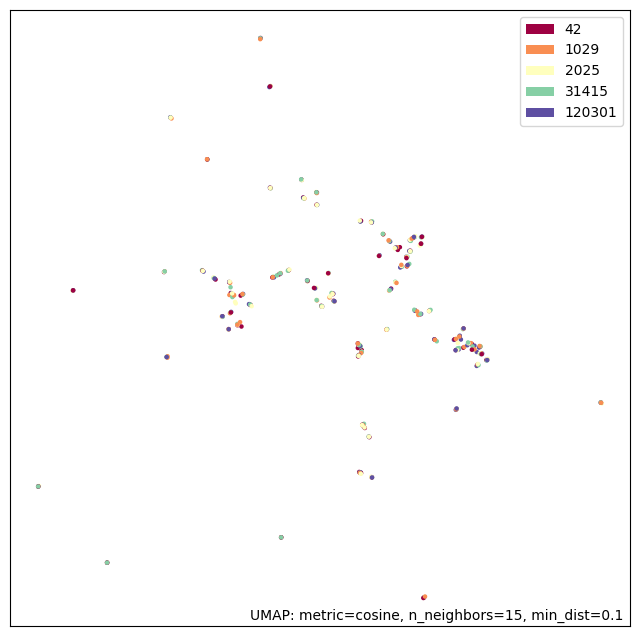

In [11]:
import umap.plot
umap.plot.points(mapper, labels=pattern_meta["seed"])

In [13]:
umap.plot.output_notebook()
p = umap.plot.interactive(mapper, labels=pattern_meta["seed"])
umap.plot.show(p)

Loading BokehJS ...